# Train, evaluate, and track a fraud model

**Goal.** Build a leakage-safe model comparison from a bounded payment run.

**Audience.** ML engineers validating a fraud feature pipeline.

**Prerequisites.** `poetry install -E ml`; no external service is required.

**Produces.** Inspection tables, temporal splits, metrics, a local artifact, and a manifest.

**Source size.** The default cells generate approximately 1,000 logical payments; increase duration and population together for a 10,000-payment run.

**Offline path.** All marked offline cells run without Docker or network services. Service cells are optional and explicitly marked in notebook metadata.

**Output.** The evaluation manifest is written to outputs/train-and-track-fraud-model/; remove that directory when you are finished experimenting.


In [1]:
!pip install fastapi uvicorn httpx

## Optional model-serving setup
The first cell installs FastAPI, Uvicorn, and HTTPX. Start the local serving adapter only after the offline model artifact has been created.

```bash
uvicorn examples.model_service.app:app --host 127.0.0.1 --port 8000
```

Set `FRAUDTWIN_MODEL_ARTIFACT` for another artifact. Stop Uvicorn with Ctrl-C; the TestClient and offline manifest remain available without a running service.


**Set up a deterministic source run**


In [2]:
import json
from datetime import timedelta
from pathlib import Path
from tempfile import TemporaryDirectory

import polars as pl

from fraudtwin.config import FraudRegimeConfig, load_config
from fraudtwin.generation import generate

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").exists()),
    Path.cwd(),
)
base = load_config(root / "configs" / "minimal.yaml")
# Scale the population so the bounded example produces about 1,000 payments.
population = base.population.model_copy(
    update={
        "customers": 200,
        "accounts": 300,
        "cards": 240,
        "devices": 240,
        "pix_keys": 160,
        "merchants": 60,
    }
)
simulation = base.simulation.model_copy(update={"duration_days": 10})
fraud = base.fraud.model_copy(update={"enabled": True, "target_rate": 0.05})
regime = FraudRegimeConfig(
    id="steady-history",
    from_time=simulation.start,
    to_time=simulation.start + timedelta(days=simulation.duration_days),
)
splits = base.dataset.splits.model_copy(
    update={
        "train_fraction": 0.20,
        "validation_fraction": 0.20,
        "test_fraction": 0.60,
        "label_delay_gap_seconds": 3600,
    }
)
dataset = base.dataset.model_copy(update={"splits": splits})
backtest = base.backtest.model_copy(update={"regimes": (regime,)})
config = base.model_copy(
    update={
        "population": population,
        "simulation": simulation,
        "fraud": fraud,
        "dataset": dataset,
        "backtest": backtest,
    }
)
data = generate(config, write=False)
run_id = data.run_id
payments = pl.DataFrame([item.model_dump(mode="json") for item in data.behavior.payments])
print({"run_id": run_id, "payments": len(payments), "events": len(data.behavior.payment_events)})

{'run_id': 'RUN-67aabdbd8cee3ad2', 'payments': 1092, 'events': 4693}


**Inspect schema, grain, and counts**


In [3]:
dataset = data.require_dataset()
fraud_ids = {item.payment_id for item in data.behavior.fraud_records if item.fraud_truth}
rows = [
    dict(row, label=("FRAUD" if row["payment_id"] in fraud_ids else "LEGITIMATE"))
    for row in dataset.rows
]
frame = dataset.frame.with_columns(pl.Series("label", [row["label"] for row in rows]))
split_summary = (
    frame.select(["split", "label"])
    .group_by("split")
    .agg(pl.len().alias("rows"), pl.col("label").eq("FRAUD").sum().alias("fraud"))
    .sort("split")
)
total = split_summary.select(
    pl.lit("total").alias("split"),
    pl.col("rows").sum().cast(pl.UInt32).alias("rows"),
    pl.col("fraud").sum().cast(pl.UInt32).alias("fraud"),
)
display(pl.concat([split_summary, total]))
assert "prediction_time" in frame.columns

split,rows,fraud
str,u32,u32
"""test""",651,40
"""train""",238,3
"""validation""",197,1
"""total""",1086,44


**Run the core operation**


In [4]:
# Check temporal boundaries and obvious leakage indicators before fitting.
times = frame.select(
    pl.col("prediction_time").min().alias("first"), pl.col("prediction_time").max().alias("last")
)
display(times)
assert "prediction_time" in frame.columns and "label" in frame.columns
print("leakage check: only point-in-time features are used; labels are evaluation targets")

first,last
"datetime[μs, UTC]","datetime[μs, UTC]"
2026-01-01 00:40:02 UTC,2026-01-10 23:57:05 UTC


leakage check: only point-in-time features are used; labels are evaluation targets


**Measure and interpret the result**


In [5]:
from fraudtwin.ml import heuristic_predictions, load_baseline_config, train_baselines

policy = load_baseline_config(root / "configs" / "ml-baselines.yaml")
heuristic = heuristic_predictions(rows)
print(f"Heuristic predictions: {len(heuristic):,}")
print(f"Configured models: {', '.join(policy.models)}")
try:
    trained = train_baselines(rows, policy, source_run_dir=None)
    print(f"Trained models: {', '.join(trained.model_artifacts or {})}")
except (RuntimeError, ValueError) as exc:
    try:
        fallback_policy = policy.model_copy(update={"models": ("logistic_regression",)})
        trained = train_baselines(rows, fallback_policy)
        print("Some configured models are unavailable; using logistic_regression for comparison.")
    except (RuntimeError, ValueError):
        fallback_policy = policy.model_copy(update={"models": ("deterministic_heuristic",)})
        trained = train_baselines(rows, fallback_policy)
        print(
            "Optional model training unavailable; "
            f"using deterministic fallback ({type(exc).__name__})."
        )

Heuristic predictions: 1,086
Configured models: logistic_regression, lightgbm, xgboost, catboost
Some configured models are unavailable; using logistic_regression for comparison.


**Exercise a parameter or failure mode**


model_id,partition,row_count,labelled_row_count,positive_count,roc_auc,pr_auc,precision,recall,f1,precision_at_fixed_fpr,recall_at_fixed_fpr,precision_at_fixed_recall,precision_at_k,recall_at_k,brier_score,calibration,thresholds,fixed_fpr_target,fixed_recall_target,ranking_k_fraction,ranking_unit,label_policy,monetary_by_currency,detection_delay_seconds_mean,detected_fraud_count,undetected_fraud_count,segment_dimension,segment_value
str,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,struct[1],struct[3],f64,f64,f64,str,str,struct[1],null,i64,i64,str,str
"""heuristic""","""train""",238,238,3,0.473759,0.019618,0.017857,0.333333,0.033898,0.0,0.0,0.017857,0.0,0.0,0.319539,{0.443504},"{0.646059,0.893859,0.646059}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{0.0,5907.81,3879.3}}",null,0,3,null,null
"""heuristic""","""validation""",197,197,1,0.938776,0.076923,0.076923,1.0,0.142857,0.0,0.0,0.076923,0.0,0.0,0.149372,{0.240197},"{0.646059,0.893859,0.646059}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{0.0,4875.0,174.67}}",null,0,1,null,null
"""heuristic""","""test""",651,651,40,0.850327,0.18204,0.142857,0.05,0.074074,0.5,0.025,0.142857,0.142857,0.025,0.088223,{0.027233},"{0.646059,0.893859,0.646059}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{1123.74,49319.53,4928.53}}",null,0,40,null,null
"""heuristic""","""test""",651,651,40,0.850327,0.18204,0.142857,0.05,0.074074,0.5,0.025,0.142857,0.142857,0.025,0.088223,{0.027233},"{0.646059,0.893859,0.646059}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{1123.74,49319.53,4928.53}}",null,0,40,"""fraud_type""","""unavailable"""
"""heuristic""","""test""",184,184,0,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0.03423,{0.063797},"{0.646059,0.893859,0.646059}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{0.0,0.0,0.0}}",null,0,0,"""payment_rail""","""ACCOUNT_TRANSFER"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""logistic_regression""","""test""",95,95,0,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,4.6260e-7,{0.000356},"{0.044928,0.044928,0.044928}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{0.0,0.0,0.0}}",null,0,0,"""time_period""","""2026-01-06"""
"""logistic_regression""","""test""",104,104,0,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,2.5191e-7,{0.000237},"{0.044928,0.044928,0.044928}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{0.0,0.0,0.0}}",null,0,0,"""time_period""","""2026-01-07"""
"""logistic_regression""","""test""",95,95,0,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,7.7324e-7,{0.000373},"{0.044928,0.044928,0.044928}",0.01,0.8,0.01,"""events""","""exclude_unresolved""","{{0.0,0.0,0.0}}",null,0,0,"""time_period""","""2026-01-08"""


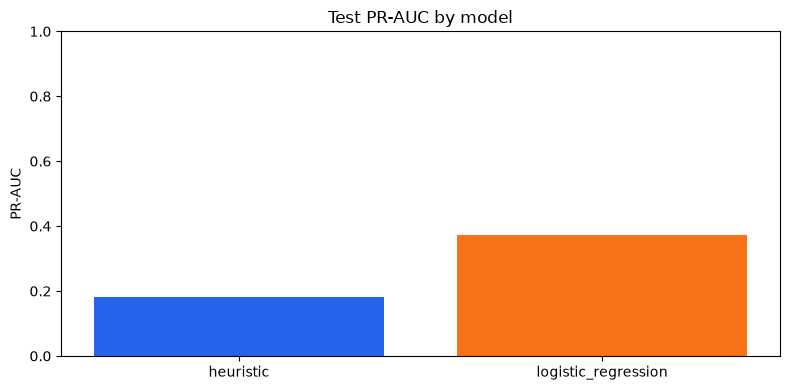

In [6]:
from fraudtwin.ml import evaluate_predictions

heuristic_result = evaluate_predictions(rows, heuristic, policy, model_id="heuristic")
trained_metrics = pl.DataFrame(list(trained.metrics))
if trained_metrics.filter(pl.col("model_id") != "deterministic_heuristic").height:
    metrics = pl.concat([pl.DataFrame(list(heuristic_result.metrics)), trained_metrics], how="diagonal_relaxed")
else:
    metrics = pl.DataFrame(list(heuristic_result.metrics))
display(metrics)
try:
    import matplotlib.pyplot as plt

    plot_metrics = (
        metrics.filter(
            pl.col("segment_dimension").is_null()
            & (pl.col("partition") == "test")
            & pl.col("pr_auc").is_not_null()
        )
        .unique(subset=["model_id"], keep="last")
        .sort("model_id")
    )
    if plot_metrics.height < 2:
        print("At least two test-set models are required for a comparison plot.")
    else:
        labels = plot_metrics["model_id"].to_list()
        fig, axis = plt.subplots(figsize=(8, 4))
        axis.bar(labels, plot_metrics["pr_auc"].to_list(), color=["#2563eb", "#f97316"])
        axis.set(title="Test PR-AUC by model", ylabel="PR-AUC")
        axis.set_ylim(0, 1)
        fig.tight_layout()
        plt.show()
        plt.close(fig)
except ImportError:
    print("Install matplotlib to render the PR-AUC plot.")

**Write a compact artifact and fingerprint**


In [7]:
out = root / "outputs" / "train-and-track-fraud-model"
out.mkdir(parents=True, exist_ok=True)
manifest = out / "evaluation-manifest.json"
manifest.write_text(
    json.dumps(heuristic_result.manifest, indent=2, default=str), encoding="utf-8"
)
print(f"Evaluation manifest: {manifest.relative_to(root)}")
print(f"Size: {manifest.stat().st_size:,} bytes")

Evaluation manifest: outputs/train-and-track-fraud-model/evaluation-manifest.json
Size: 3,284 bytes


**Verify invariants and clean up**


In [8]:
summary = {
    "run_id": run_id,
    "payments": len(data.behavior.payments),
    "payment_events": len(data.behavior.payment_events),
    "fraud_records": len(data.behavior.fraud_records),
}
assert summary["payments"] == len(payments)
assert summary["payments"] > 0
print(json.dumps(summary, indent=2, default=str))

{
  "run_id": "RUN-67aabdbd8cee3ad2",
  "payments": 1092,
  "payment_events": 4693,
  "fraud_records": 51
}


## Record the generated shape and tutorial contract.


In [9]:
summary = {
    "payments": len(data.behavior.payments),
    "events": len(data.behavior.payment_events),
}
print(summary)
assert summary["payments"] >= 0

{'payments': 1092, 'events': 4693}


## Inspect stable payment identities.


In [10]:
ids = [item.payment_id for item in data.behavior.payments]
assert len(ids) == len(set(ids))
print({"unique_payment_ids": len(ids)})

{'unique_payment_ids': 1092}


## Record the generated shape and tutorial contract.


In [11]:
summary = {
    "payments": len(data.behavior.payments),
    "events": len(data.behavior.payment_events),
}
print(summary)
assert summary["payments"] >= 0

{'payments': 1092, 'events': 4693}


In [12]:
try:
    from examples.model_service.app import create_app
    from fastapi.testclient import TestClient

    artifact_bytes = (trained.model_artifacts or {}).get("logistic_regression")
    if artifact_bytes is None:
        raise RuntimeError("a persisted logistic_regression artifact is required")
    with TemporaryDirectory(prefix="fraudtwin-serving-") as serving_dir:
        artifact_path = Path(serving_dir) / "logistic_regression.joblib"
        artifact_path.write_bytes(artifact_bytes)
        client = TestClient(create_app(artifact_path))
        health = client.get("/health")
        score = client.post(
            "/score",
            json={
                "event_id": "tutorial-9",
                "prediction_timestamp": "2026-01-01T00:00:00Z",
                "features": {},
            },
        )
        invalid = client.post(
            "/score",
            json={"event_id": "tutorial-9", "prediction_timestamp": "not-a-time", "features": {}},
        )
    print(
        {"health": health.status_code, "score": score.status_code, "invalid": invalid.status_code}
    )
except Exception as exc:
    print({"connected": False, "offline_fallback": True, "reason": type(exc).__name__})

{'connected': False, 'offline_fallback': True, 'reason': 'ModuleNotFoundError'}


In [13]:
assert heuristic_result.manifest
print({"offline_fallback": True, "metrics": len(heuristic_result.metrics)})

{'offline_fallback': True, 'metrics': 20}
